In [2]:
!pip install duckdb

   ---------------------------------------- 0.0/13.2 MB ? eta -:--:--
    --------------------------------------- 0.3/13.2 MB ? eta -:--:--
   --- ------------------------------------ 1.3/13.2 MB 4.8 MB/s eta 0:00:03
   ------- -------------------------------- 2.4/13.2 MB 4.8 MB/s eta 0:00:03
   ------- -------------------------------- 2.6/13.2 MB 4.8 MB/s eta 0:00:03
   ----------- ---------------------------- 3.7/13.2 MB 4.3 MB/s eta 0:00:03
   ------------- -------------------------- 4.5/13.2 MB 4.1 MB/s eta 0:00:03
   ---------------- ----------------------- 5.5/13.2 MB 4.0 MB/s eta 0:00:02
   ------------------- -------------------- 6.6/13.2 MB 4.2 MB/s eta 0:00:02
   ----------------------- ---------------- 7.6/13.2 MB 4.2 MB/s eta 0:00:02
   -------------------------- ------------- 8.7/13.2 MB 4.3 MB/s eta 0:00:02
   ----------------------------- ---------- 9.7/13.2 MB 4.4 MB/s eta 0:00:01
   -------------------------------- ------- 10.7/13.2 MB 4.4 MB/s eta 0:00:01
   ---------


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import duckdb 

# Veri setini yükleme
df = pd.read_csv('data/online_retail_II.csv')

print(f"Toplam Satır Sayısı: {len(df):,}")
df.head()

Toplam Satır Sayısı: 1,067,371


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
# 1. Veri tipleri ve eksik değerler
print("--- Veri Bilgisi ---")
df.info()

print("\n--- Eksik Değer Sayıları ---")
print(df.isnull().sum())

print("\n--- Temel Sayısal Özet ---")
display(df.describe())

--- Veri Bilgisi ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB

--- Eksik Değer Sayıları ---
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

--- Temel Sayısal Özet ---


,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [5]:
df.columns = [col.strip().replace(' ', '_') for col in df.columns]

# DuckDB bağlantısı kurma ve temiz tabloyu SQL ile filtreleme
query = """
CREATE OR REPLACE TABLE clean_retail AS
SELECT 
    Invoice,
    StockCode,
    Description,
    Quantity,
    TRY_CAST(InvoiceDate AS TIMESTAMP) AS InvoiceDate,
    Price,
    CAST(Customer_ID AS BIGINT) AS Customer_ID,
    Country,
    ROUND(Quantity * Price, 2) AS Total_Price
FROM df
WHERE Customer_ID IS NOT NULL
  AND Quantity > 0
  AND Price > 0
  AND Invoice NOT LIKE 'C%'
"""

duckdb.query(query)

# Temizlenen satır sayısını kontrol edelim
clean_count = duckdb.query("SELECT COUNT(*) AS row_count, COUNT(DISTINCT Customer_ID) AS unique_customers FROM clean_retail").df()
clean_count

,row_count,unique_customers
0,805549,5878


In [6]:
ref_date_df = duckdb.query("""
SELECT 
    MAX(InvoiceDate) AS max_date,
    MAX(InvoiceDate) + INTERVAL 2 DAY AS analysis_date
FROM clean_retail
""").df()

display(ref_date_df)

,max_date,analysis_date
0,2011-12-09 12:50:00,2011-12-11 12:50:00


In [7]:
rfm_query = """
WITH customer_rfm_raw AS (
    SELECT 
        Customer_ID,
        -- Recency: Analiz tarihi ile son sipariş arasındaki gün farkı
        DATEDIFF('day', MAX(InvoiceDate), (SELECT MAX(InvoiceDate) + INTERVAL 2 DAY FROM clean_retail)) AS recency,
        
        -- Frequency: Müşterinin kaç farklı fatura kestiği (sipariş sıklığı)
        COUNT(DISTINCT Invoice) AS frequency,
        
        -- Monetary: Müşterinin bıraktığı toplam net ciro
        ROUND(SUM(Total_Price), 2) AS monetary
    FROM clean_retail
    GROUP BY Customer_ID
),

rfm_scores AS (
    SELECT 
        Customer_ID,
        recency,
        frequency,
        monetary,
        -- Recency skoru: Yakın zamanda alan daha değerlidir (düşük gün = yüksek skor 5)
        --NTILE(5) GRUBU 5E BÖLER VE ONA GÖRE PUANLAR 
        NTILE(5) OVER (ORDER BY recency DESC) AS r_score,
        
        -- Frequency skoru: Çok sipariş veren daha değerlidir (yüksek sipariş = yüksek skor 5)
        NTILE(5) OVER (ORDER BY frequency ASC) AS f_score,
        
        -- Monetary skoru: Çok harcayan daha değerlidir (yüksek ciro = yüksek skor 5)
        NTILE(5) OVER (ORDER BY monetary ASC) AS m_score
    FROM customer_rfm_raw
)

SELECT 
    *,
    -- RF Skorunun metin olarak birleşimi (Segment haritası için R ve F kullanılır)
    CAST(r_score AS VARCHAR) || CAST(f_score AS VARCHAR) AS rf_score
FROM rfm_scores
"""

rfm_df = duckdb.query(rfm_query).df()
display(rfm_df.head(10))

,Customer_ID,recency,frequency,monetary,r_score,f_score,m_score,rf_score
0,14095,724,1,2.95,1,1,1,11
1,16738,299,1,3.75,2,1,1,21
2,13788,507,1,3.75,1,1,1,11
3,14792,65,1,6.20,3,2,1,32
4,15913,536,1,6.30,1,1,1,11
5,15040,543,1,7.49,1,1,1,11
6,18115,699,1,9.70,1,1,1,11
7,17378,376,1,10.95,2,1,1,21
8,17956,251,1,12.75,2,1,1,21
9,16878,86,1,13.30,3,2,1,32


In [8]:
# 1. Sektör standardı RF matris eşlemesi (Regex ile)
seg_map = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At_Risk',
    r'[1-2]5': 'Cant_Loose',
    r'3[1-2]': 'About_to_Sleep',
    r'33': 'Need_Attention',
    r'[3-4][4-5]': 'Loyal_Customers',
    r'41': 'Promising',
    r'51': 'New_Customers',
    r'[4-5][2-3]': 'Potential_Loyalists',
    r'5[4-5]': 'Champions'
}

# 2. Skorları segment isimlerine çevirme
rfm_df['segment'] = rfm_df['r_score'].astype(str) + rfm_df['f_score'].astype(str)
rfm_df['segment'] = rfm_df['segment'].replace(seg_map, regex=True)

# 3. Segment bazlı özet istatistikler tablosu
segment_summary = rfm_df.groupby('segment').agg(
    customer_count=('Customer_ID', 'count'),
    mean_recency=('recency', 'mean'),
    mean_frequency=('frequency', 'mean'),
    total_monetary=('monetary', 'sum'),
    mean_monetary=('monetary', 'mean')
).round(2).reset_index()

# Müşteri yüzdesi ve ciro payı ekleme
segment_summary['customer_share_%'] = ((segment_summary['customer_count'] / segment_summary['customer_count'].sum()) * 100).round(1)
segment_summary['revenue_share_%'] = ((segment_summary['total_monetary'] / segment_summary['total_monetary'].sum()) * 100).round(1)

# En çok ciro getirene göre sırala
segment_summary = segment_summary.sort_values(by='total_monetary', ascending=False)
display(segment_summary)

,segment,customer_count,mean_recency,mean_frequency,total_monetary,mean_monetary,customer_share_%,revenue_share_%
3,Champions,895,10.15,18.36,9226157.51,10308.56,15.2,52.0
5,Loyal_Customers,1167,66.75,9.80,4899105.49,4198.03,19.9,27.6
1,At_Risk,646,365.03,4.29,989863.56,1532.30,11.0,5.6
4,Hibernating,1642,457.47,1.31,738740.56,449.90,27.9,4.2
7,Potential_Loyalists,717,27.42,2.23,728170.17,1015.58,12.2,4.1
2,Cant_Loose,64,331.84,16.80,575018.34,8984.66,1.1,3.2
6,Need_Attention,272,113.85,3.26,345417.69,1269.92,4.6,1.9
0,About_to_Sleep,396,108.58,1.38,213638.76,539.49,6.7,1.2
8,Promising,79,46.00,1.00,27317.08,345.79,1.3,0.2


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15688\1687678825.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15688\1687678825.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


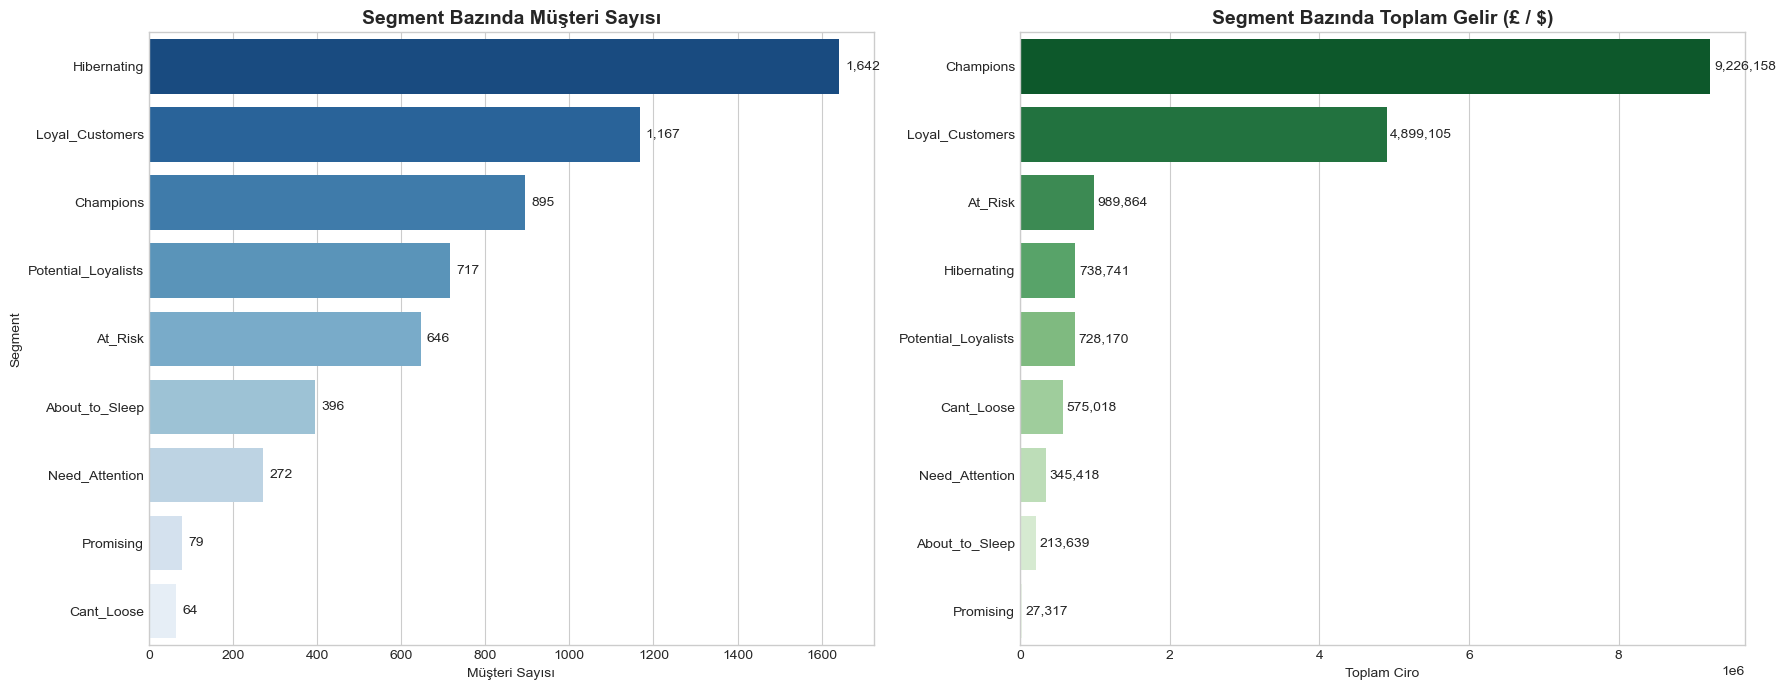

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Görselleştirme ayarları
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Grafik: Müşteri Sayısı Dağılımı (Hacim)
order_count = segment_summary.sort_values(by='customer_count', ascending=False)['segment']
sns.barplot(
    data=segment_summary, 
    x='customer_count', 
    y='segment', 
    order=order_count, 
    palette='Blues_r', 
    ax=axes[0]
)
axes[0].set_title('Segment Bazında Müşteri Sayısı', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Müşteri Sayısı')
axes[0].set_ylabel('Segment')

# Bar üstü etiketleri
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_width()):,}", 
                     (p.get_width() + 15, p.get_y() + p.get_height() / 2),
                     ha='left', va='center', fontsize=10)

# 2. Grafik: Toplam Ciro Dağılımı (Değer)
order_rev = segment_summary.sort_values(by='total_monetary', ascending=False)['segment']
sns.barplot(
    data=segment_summary, 
    x='total_monetary', 
    y='segment', 
    order=order_rev, 
    palette='Greens_r', 
    ax=axes[1]
)
axes[1].set_title('Segment Bazında Toplam Gelir (£ / $)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Toplam Ciro')
axes[1].set_ylabel('')

# Bar üstü etiketleri
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_width():,.0f}", 
                     (p.get_width() + 50000, p.get_y() + p.get_height() / 2),
                     ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('rfm_segment_dagilimi.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# 1. Müşteri bazlı RFM skorları ve segment tablosu
rfm_df.to_csv('rfm_segments.csv', index=False)

# 2. SQL ile temizlediğimiz ham sipariş hareketleri tablosu (Power BI ilişkisi için)
clean_retail_df = duckdb.query("SELECT * FROM clean_retail").df()
clean_retail_df.to_csv('clean_retail_data.csv', index=False)

print("İki dosya da başarıyla dışa aktarıldı:")
print("1. rfm_segments.csv (5,878 tekil müşteri ve segmentleri)")
print("2. clean_retail_data.csv (805,549 temiz sipariş kaydı)")

İki dosya da başarıyla dışa aktarıldı:
1. rfm_segments.csv (5,878 tekil müşteri ve segmentleri)
2. clean_retail_data.csv (805,549 temiz sipariş kaydı)
